# 04 — Novel Contributions

In [1]:
import sys
sys.path.append('..')
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap

from src.pipeline.predict_pipeline import PredictPipeline, PredictPipelineConfig
from src.components.data_ingestion import DataIngestion
from src.components.data_transformation import DataTransformationConfig, DataTransformation
from src.components.model_trainer import get_models, ModelTrainerConfig, ModelTrainer
from src.utils import compute_ge, compute_snr, AES_SBOX

sns.set_theme(style='darkgrid')
CORRECT_KEY_BYTE = 0xe0
N_TRACES_RANGE   = [10, 25, 50, 100, 200, 500]

di = DataIngestion()
X_prof, y_prof, pt_prof, X_atk, y_atk, pt_atk = di.initiate_data_ingestion()
print('Data loaded.')

c:\Coding\Coding-Lab\side-channel-ml\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data loaded.


## GE Table across all models × strategies

In [2]:
MODEL_NAMES = ['logistic_regression', 'decision_tree', 'random_forest', 'xgboost', 'svm', 'mlp']
STRATEGIES  = ['snr', 'anova', 'pca']
K = 50

ge_table = {}

for strategy in STRATEGIES:
    cfg_t = DataTransformationConfig(strategy=strategy, k=K, n_components=K)
    dt    = DataTransformation(cfg_t)
    _, X_atk_t, _ = dt.initiate_data_transformation(X_prof, y_prof, X_atk)

    for model_name in MODEL_NAMES:
        model_path = f'artifacts/models/{model_name}_{strategy}_k{K}.joblib'
        try:
            model = joblib.load(model_path)
            probs = model.predict_proba(X_atk_t)
            ge    = compute_ge(probs, pt_atk, CORRECT_KEY_BYTE, n_traces_range=[500], n_experiments=100)
            ge_table[(strategy, model_name)] = round(ge[0], 2)
            print(f'{strategy:5s} | {model_name:<22} | GE@500 = {ge[0]:.2f}')
        except FileNotFoundError:
            ge_table[(strategy, model_name)] = None
            print(f'{strategy:5s} | {model_name:<22} | NOT FOUND ')

joblib.dump(ge_table, 'artifacts/models/ge_table.joblib')

snr   | logistic_regression    | GE@500 = 154.88
snr   | decision_tree          | GE@500 = 164.96
snr   | random_forest          | GE@500 = 130.89
snr   | xgboost                | GE@500 = 110.06
snr   | svm                    | GE@500 = 128.54
snr   | mlp                    | GE@500 = 53.49
anova | logistic_regression    | GE@500 = 161.65
anova | decision_tree          | GE@500 = 113.29
anova | random_forest          | GE@500 = 160.93
anova | xgboost                | GE@500 = 146.19
anova | svm                    | NOT FOUND (run Hour 3 grid first)
anova | mlp                    | GE@500 = 138.23
pca   | logistic_regression    | GE@500 = 157.91
pca   | decision_tree          | GE@500 = 100.75
pca   | random_forest          | GE@500 = 135.14
pca   | xgboost                | GE@500 = 102.07
pca   | svm                    | NOT FOUND (run Hour 3 grid first)
pca   | mlp                    | GE@500 = 24.70


['artifacts/models/ge_table.joblib']

In [4]:
rows = []
for (strategy, model_name), ge_val in ge_table.items():
    rows.append({'Model': model_name, 'Strategy': strategy, 'GE@500': ge_val})

df_ge = pd.DataFrame(rows).pivot(index='Model', columns='Strategy', values='GE@500')
df_ge = df_ge[['snr', 'anova', 'pca']] 
print('\n=== Table 2: GE@500 traces ===')
display(df_ge)


=== Table 2: GE@500 traces ===


Strategy,snr,anova,pca
Model,,,
decision_tree,164.96,113.29,100.75
logistic_regression,154.88,161.65,157.91
mlp,53.49,138.23,24.70
random_forest,130.89,160.93,135.14
svm,128.54,NaN,NaN
xgboost,110.06,146.19,102.07


## SHAP Leakage Localization

In [6]:
print(type(shap_values))
if isinstance(shap_values, list):
    print(f'List of {len(shap_values)} arrays, each shape: {shap_values[0].shape}')
else:
    print(f'Array shape: {shap_values.shape}')

if isinstance(shap_values, list):
    mean_abs_shap = np.mean([np.abs(sv) for sv in shap_values], axis=0).mean(axis=0)
else:
    mean_abs_shap = np.abs(shap_values).mean(axis=(0, 2))

print(f'SHAP components after fix: {mean_abs_shap.shape[0]}')
print(f'Top 5 most important PCA components: {np.argsort(mean_abs_shap)[::-1][:5]}')

<class 'numpy.ndarray'>
Array shape: (100, 100, 9)
SHAP components after fix: 100
Top 5 most important PCA components: [0 4 6 2 5]


100%|██████████| 100/100 [00:07<00:00, 14.20it/s]


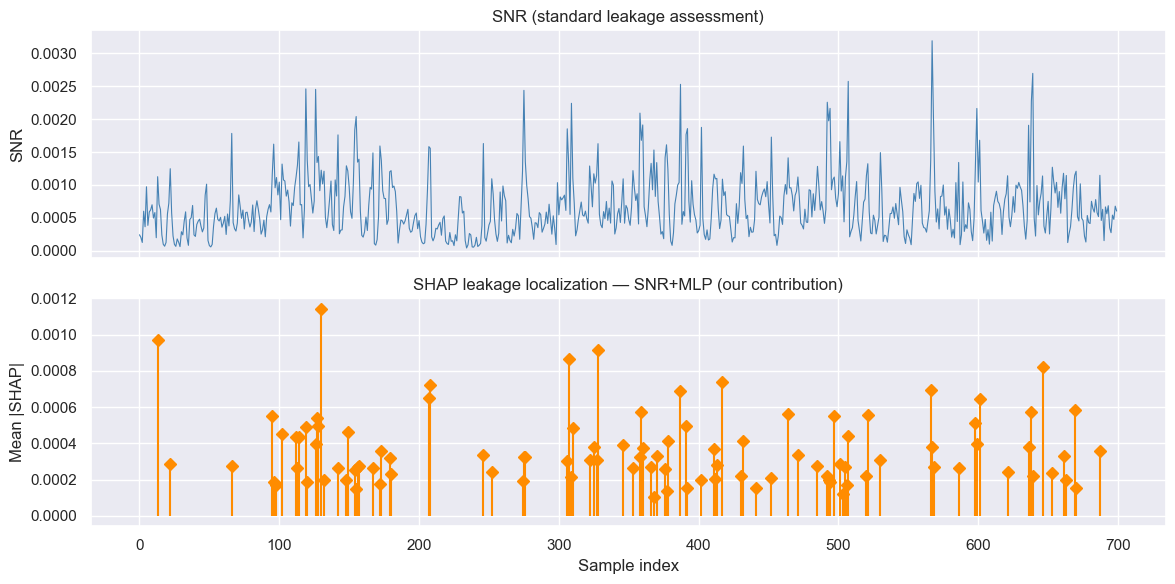

Top-10 overlap between SNR and SHAP (SNR+MLP): 1/10


In [8]:
best_model_snr  = joblib.load('artifacts/models/mlp_snr_k100.joblib')
transformer_snr = joblib.load('artifacts/models/transformer_snr_k100.joblib')

X_prof_snr = transformer_snr.transform(X_prof)
X_atk_snr  = transformer_snr.transform(X_atk)

background_snr = shap.sample(X_prof_snr, 100)
explainer_snr  = shap.KernelExplainer(best_model_snr.predict_proba, background_snr)
shap_values_snr = explainer_snr.shap_values(X_atk_snr[:100], nsamples=200)

mean_abs_shap_snr = np.abs(shap_values_snr).mean(axis=(0, 2))  # shape (100,)

poi_indices = transformer_snr.selected_indices  # shape (100,)
shap_on_trace = np.zeros(700)
shap_on_trace[poi_indices] = mean_abs_shap_snr

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(snr, linewidth=0.8, color='steelblue')
axes[0].set_ylabel('SNR')
axes[0].set_title('SNR (standard leakage assessment)')

axes[1].stem(poi_indices, mean_abs_shap_snr, linefmt='darkorange', markerfmt='D', basefmt=' ')
axes[1].set_ylabel('Mean |SHAP|')
axes[1].set_xlabel('Sample index')
axes[1].set_title('SHAP leakage localization — SNR+MLP (our contribution)')

plt.tight_layout()
plt.savefig('artifacts/raw/plot_shap_snr_leakage.png', dpi=150)
plt.show()

snr_top10  = set(np.argsort(snr)[-10:])
shap_top10 = set(np.argsort(shap_on_trace)[-10:])
overlap    = snr_top10 & shap_top10
print(f'Top-10 overlap between SNR and SHAP (SNR+MLP): {len(overlap)}/10')

## HW vs Identity Leakage Model

In [10]:
TARGET_BYTE = 2

y_prof_id = np.array([
    AES_SBOX[int(pt[TARGET_BYTE]) ^ CORRECT_KEY_BYTE]
    for pt in pt_prof
])
y_atk_id = np.array([
    AES_SBOX[int(pt[TARGET_BYTE]) ^ CORRECT_KEY_BYTE]
    for pt in pt_atk
])

print(f'ID label unique classes: {len(np.unique(y_prof_id))}')
print(f'HW label unique classes: {len(np.unique(y_prof))}')

ID label unique classes: 256
HW label unique classes: 9


In [11]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder

cfg_t_id = DataTransformationConfig(strategy='pca', k=100, n_components=100)
dt_id    = DataTransformation(cfg_t_id)
X_prof_id_t, X_atk_id_t, transformer_id = dt_id.initiate_data_transformation(
    X_prof, y_prof_id, X_atk
)

le = LabelEncoder()
y_prof_id_enc = le.fit_transform(y_prof_id)

mlp_id = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    activation='relu', max_iter=200,
    early_stopping=True, random_state=42
)
mlp_id.fit(X_prof_id_t, y_prof_id_enc)
joblib.dump(mlp_id, 'artifacts/models/mlp_id_pca_k100.joblib')
print('Identity MLP trained and saved.')

Identity MLP trained and saved.


In [12]:
def compute_ge_identity(model, le, X_atk_t, pt_atk, correct_key,
                        n_traces_range, n_experiments=100):
    """GE for Identity model — scores log P(ID=SBox[p^k]) across traces."""
    probs = model.predict_proba(X_atk_t)
    ge_values = []

    for n_traces in n_traces_range:
        ranks = []
        for _ in range(n_experiments):
            idx = np.random.choice(len(pt_atk), n_traces, replace=False)
            scores = np.zeros(256)
            for k_hyp in range(256):
                id_hyp  = [AES_SBOX[int(pt_atk[i, TARGET_BYTE]) ^ k_hyp] for i in idx]
                encoded = le.transform(id_hyp)
                scores[k_hyp] = sum(
                    np.log(probs[i, enc] + 1e-9)
                    for i, enc in zip(idx, encoded)
                )
            rank = int(np.where(np.argsort(scores)[::-1] == correct_key)[0][0])
            ranks.append(rank)
        ge_values.append(float(np.mean(ranks)))

    return ge_values

N_TRACES_RANGE = [10, 25, 50, 100, 200, 500]

mlp_hw         = joblib.load('artifacts/models/mlp_pca_k100.joblib')
transformer_hw = joblib.load('artifacts/models/transformer_pca_n100.joblib')
X_atk_hw_t    = transformer_hw.transform(X_atk)
probs_hw       = mlp_hw.predict_proba(X_atk_hw_t)

ge_hw = compute_ge(
    probs_hw, pt_atk, CORRECT_KEY_BYTE,
    n_traces_range=N_TRACES_RANGE, n_experiments=100
)
ge_id = compute_ge_identity(
    mlp_id, le, X_atk_id_t, pt_atk, CORRECT_KEY_BYTE,
    n_traces_range=N_TRACES_RANGE, n_experiments=100
)

joblib.dump({'hw': ge_hw, 'id': ge_id}, 'artifacts/models/ge_hw_vs_id.joblib')
print('GE comparison complete.')

GE comparison complete.


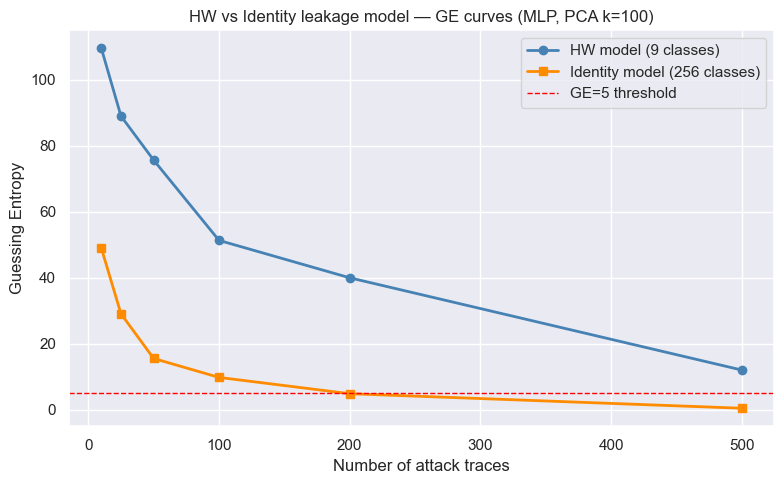


=== Table 3: HW vs Identity (MLP, PCA k=100) ===
Model          GE@100   GE@500      NtD
HW              51.34    12.03     None
Identity         9.81     0.46      500


In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(N_TRACES_RANGE, ge_hw, marker='o', color='steelblue',
        label='HW model (9 classes)', linewidth=2)
ax.plot(N_TRACES_RANGE, ge_id, marker='s', color='darkorange',
        label='Identity model (256 classes)', linewidth=2)
ax.axhline(5, color='red', linestyle='--', linewidth=1, label='GE=5 threshold')
ax.set_xlabel('Number of attack traces')
ax.set_ylabel('Guessing Entropy')
ax.set_title('HW vs Identity leakage model — GE curves (MLP, PCA k=100)')
ax.legend()
plt.tight_layout()
plt.savefig('artifacts/raw/plot_hw_vs_id.png', dpi=150)
plt.show()

ntd_hw = next((n for n, ge in zip(N_TRACES_RANGE, ge_hw) if ge < 1), None)
ntd_id = next((n for n, ge in zip(N_TRACES_RANGE, ge_id) if ge < 1), None)

print('\n=== Table 3: HW vs Identity (MLP, PCA k=100) ===')
print(f'{"Model":<12} {"GE@100":>8} {"GE@500":>8} {"NtD":>8}')
print(f'{"HW":<12} {ge_hw[N_TRACES_RANGE.index(100)]:>8.2f} ' f'{ge_hw[-1]:>8.2f} {str(ntd_hw):>8}')
print(f'{"Identity":<12} {ge_id[N_TRACES_RANGE.index(100)]:>8.2f} ' f'{ge_id[-1]:>8.2f} {str(ntd_id):>8}')